<a href="https://colab.research.google.com/github/ekoshkaa/is_4487_base/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 10 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data
3. Fit a model
4. Test the accuracy of the model
6.  Use the model to predict on a new dataset (without the target)

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary


| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |

### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [1]:
#Import libraries  🔧
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

## Step 1: Initial Data Understanding

### Do the following:
 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to Assignments > DataSets)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [4]:
from google.colab import files
uploaded = files.upload()


Saving adviseinvest_historical_data.csv to adviseinvest_historical_data.csv


In [5]:
#Import the data 🔧
df = pd.read_csv('adviseinvest_historical_data.csv')

In [3]:
# Download the dataset from GitHub
!wget https://raw.githubusercontent.com/byui-cse/cse450-course/main/data/adviseinvest_historical_data.csv

--2025-11-03 06:22:46--  https://raw.githubusercontent.com/byui-cse/cse450-course/main/data/adviseinvest_historical_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-11-03 06:22:46 ERROR 404: Not Found.



In [6]:
#View the datatypes 🔧
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29504 non-null  int64  
 1   income          29504 non-null  int64  
 2   female          29504 non-null  object 
 3   age             29504 non-null  int64  
 4   job             29504 non-null  int64  
 5   num_dependents  29504 non-null  int64  
 6   rent            29504 non-null  int64  
 7   own_res         29504 non-null  int64  
 8   new_car         29502 non-null  float64
 9   chk_acct        29504 non-null  int64  
 10  sav_acct        29504 non-null  int64  
 11  num_accts       29504 non-null  int64  
 12  mobile          29504 non-null  int64  
 13  product         29504 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 3.2+ MB
None


,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,1,13520,0,23,0,1,1,0,0.0,0,2,0,1,2
1,0,14780,0,22,2,1,0,1,0.0,3,0,3,0,0
2,1,37570,0,62,2,1,0,0,1.0,3,0,4,0,4
3,0,12450,0,33,2,1,0,1,0.0,1,0,2,0,0
4,0,12400,0,48,1,2,0,0,1.0,2,1,4,0,0


In [7]:
#Describe the data 🔧
display(df.describe())

,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


## Step 2: Data Preparation

### 2.1: Data Cleanup
- Remove any variables that are not relevant to our analysis (be sure not to delete too many variables, you may need them in the near future!)
- Clean up the data and put it in a new datafram named "df_clean"


In [9]:
#delete outliers 🔧
df = df[df['income'] < 500000]     # remove extreme incomes
df = df[df['age'].between(18, 90)] # keep only realistic ages

print("After removing outliers:", df.shape)

After removing outliers: (29503, 14)


In [11]:
#remove variables that are not helpful 🔧
df_clean = df.drop(columns=['product'])  # Product already encodes purchase info

print("Remaining columns:", df_clean.columns.tolist())

Remaining columns: ['answered', 'income', 'female', 'age', 'job', 'num_dependents', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'num_accts', 'mobile']


In [12]:
#cleanup any missing or non-standardized data 🔧
print("Duplicates removed:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()

print("Missing values before cleanup:")
print(df_clean.isnull().sum())

# Fill or drop missing values
df_clean = df_clean.dropna()  # easiest: drop rows with missing data

# Confirm cleanup
print("Missing values after cleanup:")
print(df_clean.isnull().sum())
print("Final dataset shape:", df_clean.shape)

Duplicates removed: 29035
Missing values before cleanup:
answered          0
income            0
female            0
age               0
job               0
num_dependents    0
rent              0
own_res           0
new_car           2
chk_acct          0
sav_acct          0
num_accts         0
mobile            0
dtype: int64
Missing values after cleanup:
answered          0
income            0
female            0
age               0
job               0
num_dependents    0
rent              0
own_res           0
new_car           0
chk_acct          0
sav_acct          0
num_accts         0
mobile            0
dtype: int64
Final dataset shape: (466, 13)


### 2.2: Standardize variables

 - Change "answered" to yes/no and make it categorical
 - Convert any variables that should be an integer into an integer

In [13]:
# Convert answered to categorical 🔧
df_clean['answered'] = df_clean['answered'].map({1: 'yes', 0: 'no'})
df_clean['answered'] = df_clean['answered'].astype('category')
print(df_clean['answered'].value_counts())

answered
yes    255
no     211
Name: count, dtype: int64


In [14]:
# Convert variables to integer data type 🔧
# Identify columns that should be integers based on the data dictionary and info
int_cols = ['job', 'num_dependents', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'num_accts', 'mobile']

for col in int_cols:
    # Convert to numeric, coercing errors to NaN, then fill NaN with a placeholder before converting to int
    # We use errors='coerce' in case there are non-numeric values that were not caught before
    # We fillna(0) or another appropriate value if there were NaNs from coercion,
    # although previous steps aimed to drop NaNs. .astype(int) requires no NaNs.
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0).astype(int)

print("Data types after converting to integer:")
print(df_clean.dtypes)

Data types after converting to integer:
answered          category
income               int64
female              object
age                  int64
job                  int64
num_dependents       int64
rent                 int64
own_res              int64
new_car              int64
chk_acct             int64
sav_acct             int64
num_accts            int64
mobile               int64
dtype: object


### 2.3 Convert variables to categorical

- Find at least 8 variables that would be appropriate to convert to categories

In [15]:
# Convert variables to categorical 🔧
categorical_cols = ['female', 'job', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'mobile']

for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

print("Data types after converting to categorical:")
print(df_clean.dtypes)

Data types after converting to categorical:
answered          category
income               int64
female            category
age                  int64
job               category
num_dependents       int64
rent              category
own_res           category
new_car           category
chk_acct          category
sav_acct          category
num_accts            int64
mobile            category
dtype: object


# Step 3: Exploratory Data Analysis (EDA)

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted



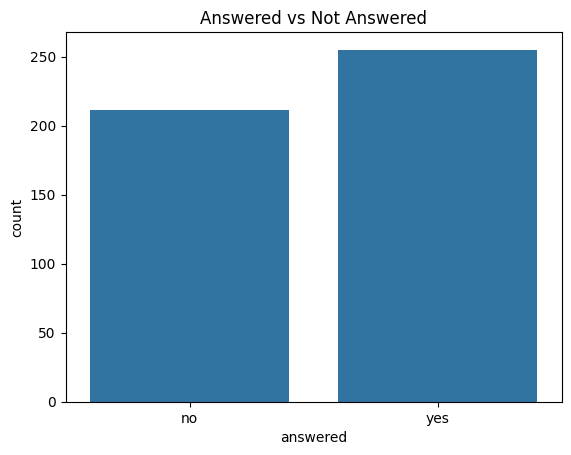

In [17]:
# Chart 1 🔧
sns.countplot(x='answered', data=df_clean)
plt.title('Answered vs Not Answered')
plt.show()

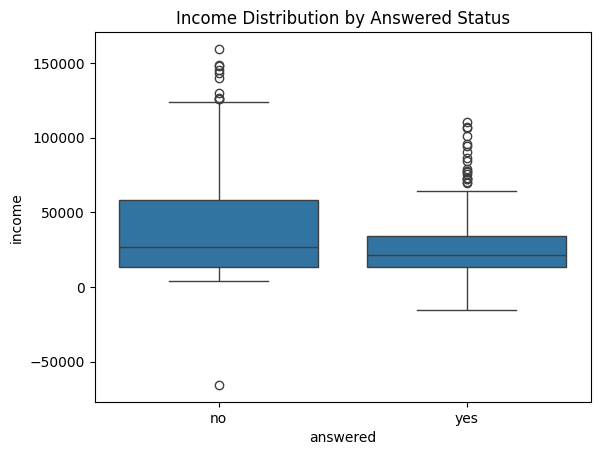

In [19]:
# Chart 2 🔧
sns.boxplot(x='answered', y='income', data=df_clean)
plt.title('Income Distribution by Answered Status')
plt.show()

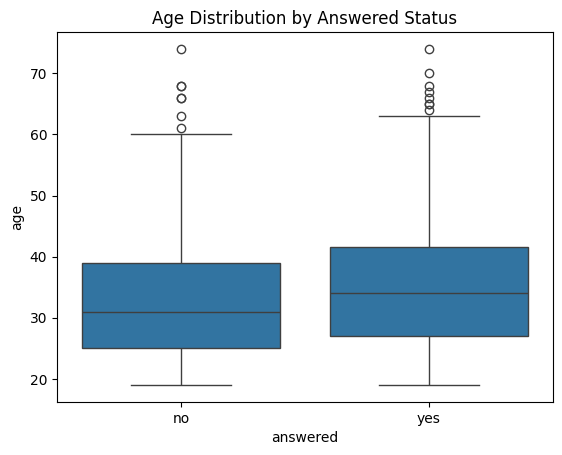

In [21]:
# Chart 3 🔧
sns.boxplot(x='answered', y='age', data=df_clean)
plt.title('Age Distribution by Answered Status')
plt.show()

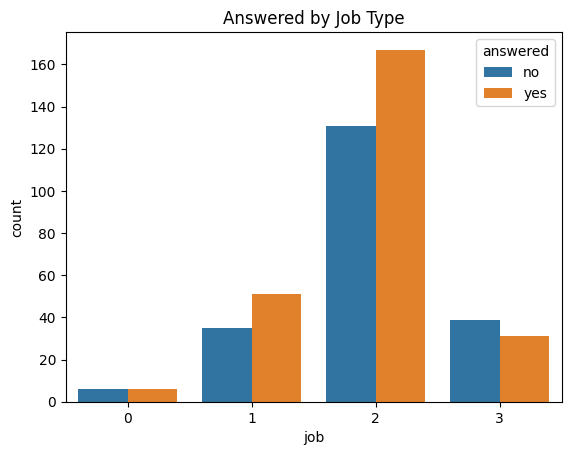

In [23]:
# Chart 4 🔧
sns.countplot(x='job', hue='answered', data=df_clean)
plt.title('Answered by Job Type')
plt.show()

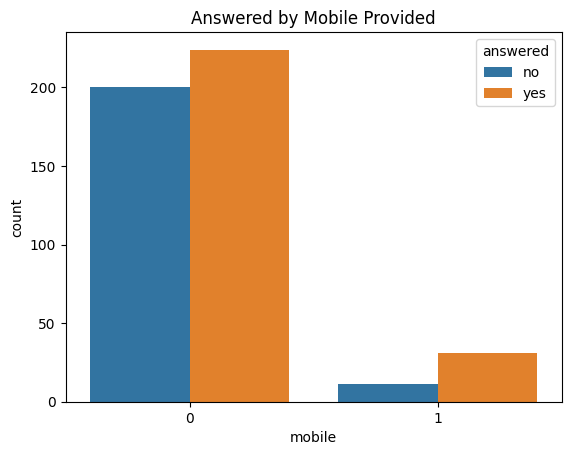

In [25]:
# Chart 5 🔧
sns.countplot(x='mobile', hue='answered', data=df_clean)
plt.title('Answered by Mobile Provided')
plt.show()

## Step 4: Modeling

### 4.1: Calculate the base probability of answering

If we use no model at all, how good is our chance of predicting someone leaving?  Use a calculation to find the chances of someone leaving.

In [27]:
#get the default probability 🔧
base_prob = df_clean['answered'].value_counts(normalize=True)
print("Base Probability:\n", base_prob)

Base Probability:
 answered
yes    0.54721
no     0.45279
Name: proportion, dtype: float64


### 4.2: Split the training and testing datasets

- split df_clean using train_test_split function
- all variables except answered should be in the x variable
- answered is in the y variable


In [31]:
# Split data into training and testing sets 🔧

X = df_clean.drop('answered', axis=1)
y = df_clean['answered']

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### 4.3: Create a Decision Tree
- Use all available attributes (except those that were eliminated in step 3)
- It is recommended to use the type "entropy" and a max_depth of 4

In [33]:
# Create a Decision Tree 🔧

# One-hot encode the 'female' column as it's a categorical variable
X_train_encoded = pd.get_dummies(X_train, columns=['female'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['female'], drop_first=True)


model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
model.fit(X_train_encoded, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

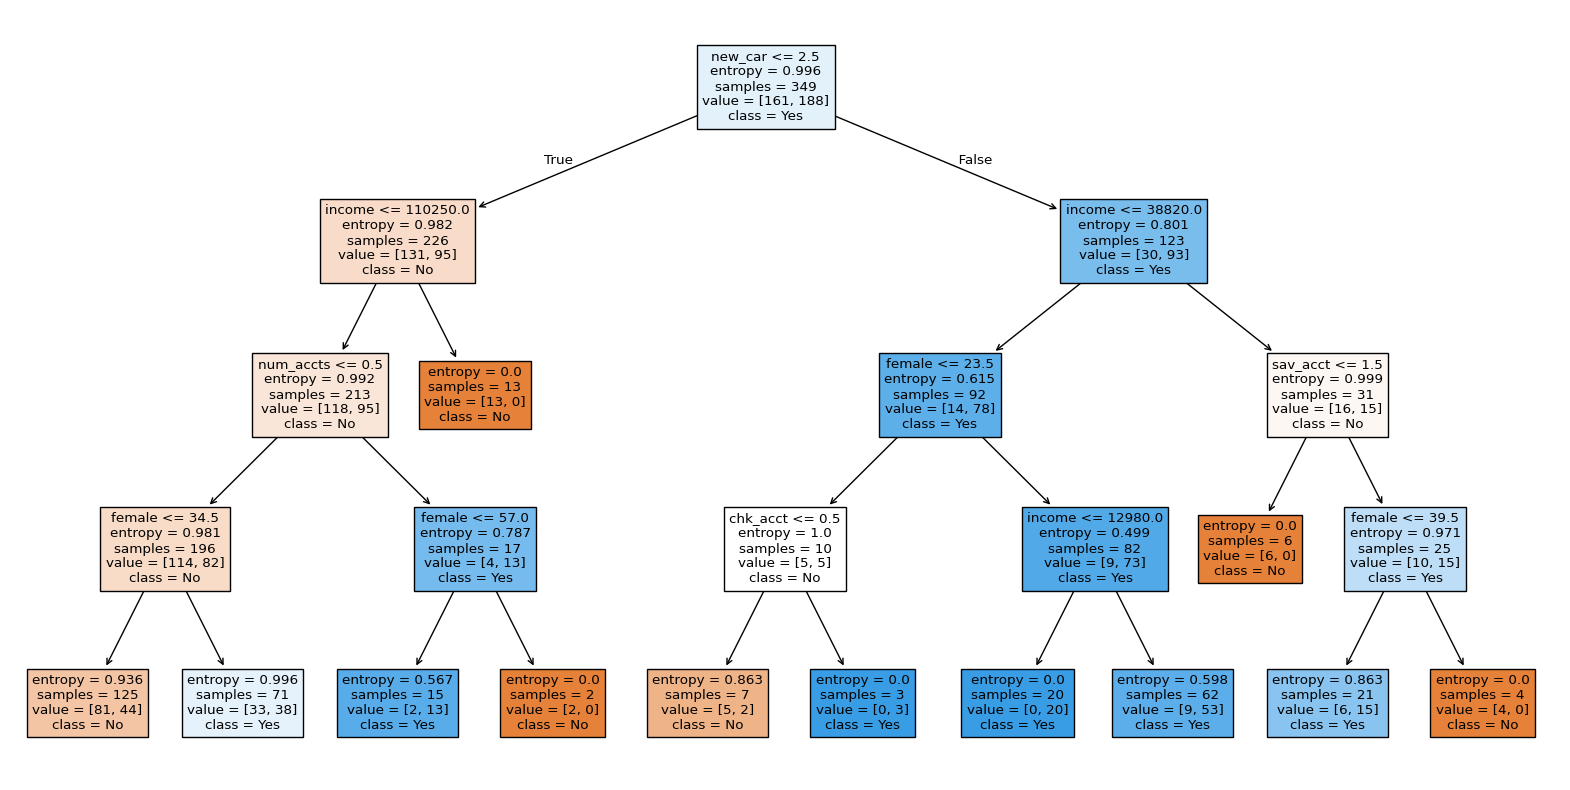

In [34]:
#display (visualize) the tree 🔧
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

### 4.4: What is the accuracy?

This should be better than the base probability, or you have failed in your objective

In [35]:
#calculate the probability for your tree 🔧
y_pred = model.predict(X_test_encoded)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Decision Tree model: {accuracy:.4f}")

Accuracy of the Decision Tree model: 0.6581


### 4.5: Create a confusion matrix

This will show false positives, true positives, etc.

In [36]:
#create a basic confusion matrix 🔧
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[31 19]
 [21 46]]


Create a more visual, interpretable version of the matrix

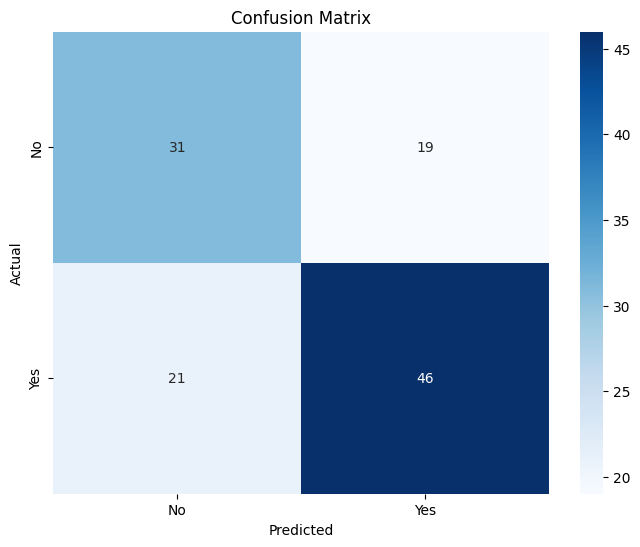

In [37]:
#Create a beautiful matrix; hint - try using Seaborn Heatmap 🔧
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Step 5: Evaluate the Model

**Assumptions**

One of the simplifying assumptions we will make in this project is that all the customers who answer the phone will purchase a product. (This assumption is actually verified by the data.) To model "answered" in this case is therefore equivalent to modeling "purchased."

There are costs and benefits in this case. We will assume that customers purchase a product for 100 dollars. This was the average cost of AdviseInvest products, according to the Director of Sales.  Also, as we learned in the interview, the agent time to make the sale is worth 25 dollars. Profit would therefore be \$75 dollars for an answered call and a purchase. In sum:

**Benefit**: True positive. The customer is predicted to answer, does answer, and purchases a product for 100 dollars for a profit of 100 - 25 = 75.

**Cost**: False positive. The customer is predicted to answer, but does not answer, so there is a loss of 25. (We assume the agent cannot schedule another call at the last minute, or spends the entire time slot trying to make the call.)

When you create a calculation you can use:
- True answered * 75 -> These people purchased
- False answered * 25 -> You can't schedule another call

For this exercise, we propose that customers who are not predicted to answer will not be called, so there would be no benefits and no costs for them.  

### 5.1 Calculate the Profit Using the Model

In [38]:
# Write a calcuation for the profit from your model 🔧

# conf_matrix is in the format [[TN, FP], [FN, TP]]
tn, fp, fn, tp = conf_matrix.ravel()

profit_model = (tp * 75) - (fp * 25)
print(f"Profit using the model: ${profit_model}")

Profit using the model: $2975


### 5.2 Compare to the Default Profit

How much profit (revenue - costs) could be expected if all customers are called? We can consider this a baseline case for profit since it does not require a model.

In other words, to calculate profit in this baseline scenario treat the customers who answer as true positives treat the customers who do not answer as false positives.

In [39]:
#Write a calculation for the overall profit without using the model (default) 🔧

# In the default scenario, all customers are called.
# True Positives in this context are the customers who actually answered (from y_test).
# False Positives are the customers who did not answer (from y_test).

# Count the number of 'yes' (answered) and 'no' (not answered) in the test set
answered_count = y_test[y_test == 'yes'].count()
not_answered_count = y_test[y_test == 'no'].count()

# Calculate default profit: (answered * 75) - (not_answered * 25)
profit_default = (answered_count * 75) - (not_answered_count * 25)

print(f"Default profit (calling all customers): ${profit_default}")

Default profit (calling all customers): $3775


### 5.3 Tune the Model
- Adjust the size or shape of the tree, then test the accuracy
- Keep changing these parameters until you end up with a tree with accuracy that is better than the initial model

In [40]:
# Create a new version of the tree with new parameters 🔧

# Create a new model instance with different parameters (e.g., increased max_depth)
model_tuned = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# Fit the new model to the training data
model_tuned.fit(X_train_encoded, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [41]:
# Calculate a new probability 🔧
y_pred_tuned = model_tuned.predict(X_test_encoded)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy of the Tuned Decision Tree model: {accuracy_tuned:.4f}")

Accuracy of the Tuned Decision Tree model: 0.7436


### 5.4 Apply the Model to New Customers
- Import the "adviseinvest_new_customer_data.csv" file
- Using the tree model, predict each customer for the target variable  by feeding the new customer data into the model

In [ ]:
from google.colab import files
uploaded = files.upload()

# Load the uploaded file into a DataFrame
file_name = list(uploaded.keys())[0]
df_new_customers = pd.read_csv(file_name)
display(df_new_customers.head())

In [ ]:
new_df = pd.read_csv('adviseinvest_new_customer_data.csv')
new_df.head()

In [46]:
#Predict the number of customers who will be yes/no for the target variable

# Preprocess the new customer data: one-hot encode the 'female' column
df_new_customers_encoded = pd.get_dummies(df_new_customers, columns=['female'], drop_first=True)

# Ensure the columns in the new data match the columns in the training data
# This is important if the new data is missing any columns or has extra ones
# For simplicity here, assuming the columns are the same except for 'female' encoding
# If columns differ significantly, more complex alignment might be needed
missing_cols = set(X_train_encoded.columns) - set(df_new_customers_encoded.columns)
for c in missing_cols:
    df_new_customers_encoded[c] = 0
# Ensure the order of columns is the same
df_new_customers_encoded = df_new_customers_encoded[X_train_encoded.columns]


new_predictions = model_tuned.predict(df_new_customers_encoded)
df_new_customers['Predicted_Answered'] = new_predictions

print(df_new_customers.head())
print(df_new_customers['Predicted_Answered'].value_counts())

SyntaxError: invalid character '🔧' (U+1F527) (ipython-input-3157909463.py, line 2)

# Step 6: Conclusion
### 6.1: Did we improve our profit using the model?  

Write your conclusion notes below:  🔧

### 6.2: How could the model be utilized by the business?

Write your recommendations below:  🔧

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_10_LastnameFirstname.ipynb"